In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200
df = pd.DataFrame({
    'time' : pd.date_range('2026-03-01', periods = n, freq = 's'),
    'temp' : np.random.normal(450, 5, n),
    'pressure' : np.random.normal(1.0, 0.05, n),
    'vibration' : np.random.normal(0.3, 0.1, n)
})

print(df.shape)

idx = np.random.choice(df.index, 30, replace = False)
df.loc[idx, 'temp'] = np.nan

df.loc[df.index[:5], 'temp'] = 9999

df = pd.concat([df, df.iloc[:3]], ignore_index = True)

df['pressure'] = df['pressure'].astype(str)
df.to_csv('messy.csv', index = False)

(200, 4)


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('messy.csv')

print(df.info(), '\n')
print(df.isnull().sum(), '\n')
print(df.duplicated().sum(), '\n')
print(df.describe(), '\n')

<class 'pandas.DataFrame'>
RangeIndex: 203 entries, 0 to 202
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       203 non-null    str    
 1   temp       174 non-null    float64
 2   pressure   203 non-null    float64
 3   vibration  203 non-null    float64
dtypes: float64(3), str(1)
memory usage: 6.5 KB
None 

time          0
temp         29
pressure      0
vibration     0
dtype: int64 

3 

              temp    pressure   vibration
count   174.000000  203.000000  203.000000
mean    888.917376    1.004723    0.290483
std    2005.700126    0.049144    0.099296
min     436.901274    0.837937    0.052836
25%     446.475030    0.970010    0.220512
50%     450.340228    1.004850    0.291088
75%     453.742832    1.034410    0.356678
max    9999.000000    1.192637    0.607888 



In [ ]:
df_drop = df.dropna()
print(len(df), '->' , len(df_drop), '\n')

df2 = df.dropna(subset = ['temp'])

df3 = df.dropna(axis = 1, thresh = len(df) * 0.5)


203 -> 174 



In [8]:
df_mean = df.copy()
df_mean['temp'] = df_mean['temp'].fillna(df_mean['temp'].mean())

df_median = df.copy()
df_median['temp'] = df_median['temp'].fillna(df_median['temp'].median())

df_ffill = df.copy()
df_ffill['temp'] = df_ffill['temp'].ffill()

print("원본 결측치 개수")
print(df['temp'].isnull().sum(), '\n')

print("평균 대체 후 결측치 개수")
print(df_mean['temp'].isnull().sum(), '\n')

print("중앙값 대체 후 결측치 개수")
print(df_median['temp'].isnull().sum(), '\n')

print("ffill 대체 후 결측치 개수")
print(df_ffill['temp'].isnull().sum(), '\n')

원본 결측치 개수
29 

평균 대체 후 결측치 개수
0 

중앙값 대체 후 결측치 개수
0 

ffill 대체 후 결측치 개수
0 



In [9]:
temp_data = df['temp'].dropna()
Q1 = temp_data.quantile(0.25)
Q3 = temp_data.quantile(0.75)
IQR = Q3 - Q1
low = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR

print("Q1 : ", Q1, '\n')
print("Q3 : ", Q3, '\n')
print("IQR : ", IQR, '\n')
print("정상 범위 : ", low, " ~ ", high, '\n')

mask = (df['temp'] >= low) & (df['temp'] <= high)
df_clean = df[mask]
print("원본 행 개수 : ", len(df), '\n')
print("IQR 이상치 제거 후 행 개수 : ", len(df_clean), '\n')
print("이상치 제거 후 temp 최대값 : ", df_clean['temp'].max())

Q1 :  446.47502968201866 

Q3 :  453.74283209756965 

IQR :  7.267802415550989 

정상 범위 :  435.57332605869215  ~  464.6445357208961 

원본 행 개수 :  203 

IQR 이상치 제거 후 행 개수 :  166 

이상치 제거 후 temp 최대값 :  463.6008458329481


In [ ]:
temp_data = df['temp'].dropna()
mean = temp_data.mean()
std = temp_data.std()
df_z = df.copy()
df_z['z'] = (df_z['temp'] - mean) / std
df_z_clean = df_z[df_z['z'].abs() <= 3]
df_z_clean = df_z_clean.drop(columns = 'z')
print("Z-score 기준 이상치 제거 후 행 개수 : ", len(df_z_clean))
print("Z-score 기준 제거 후 temp 최대값 : ", df_z_clean['temp'].max())

Z-score 기준 이상치 제거 후 행 개수 :  166
Z-score 기준 제거 후 temp 최대값 :  463.6008458329481


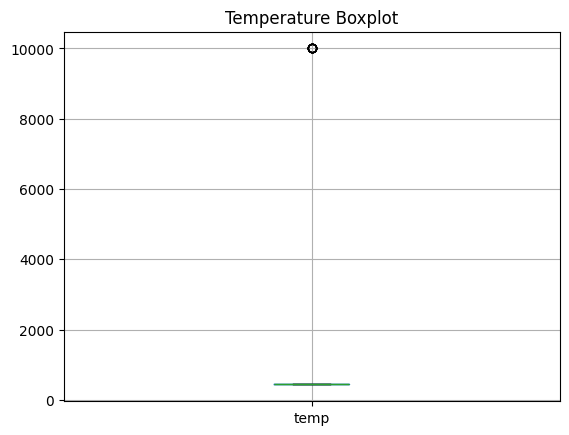

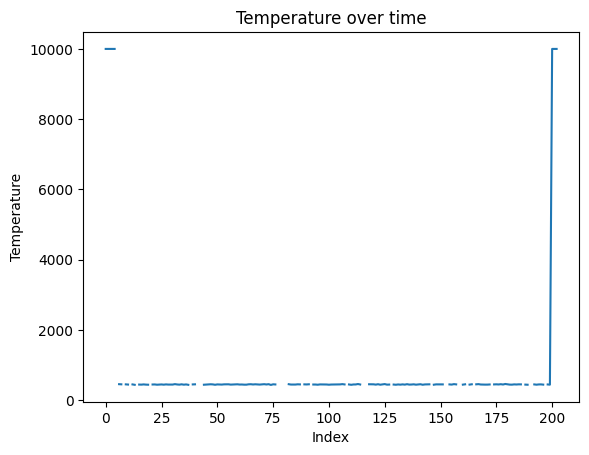

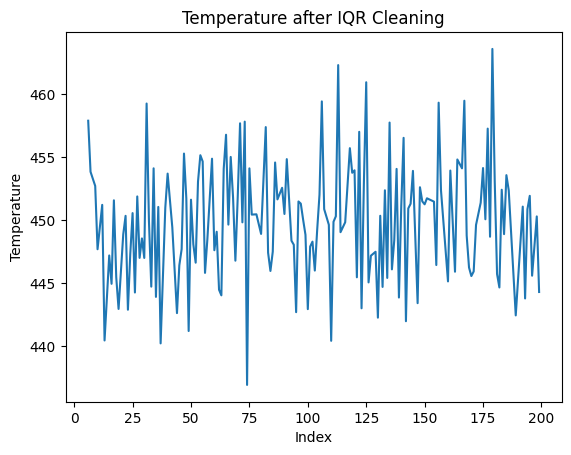

In [11]:
import matplotlib.pyplot as plt

df.boxplot(column = 'temp')
plt.title('Temperature Boxplot')
plt.show()

df['temp'].plot(title = 'Temperature over time')
plt.xlabel('Index')
plt.ylabel('Temperature')
plt.show()

df_clean['temp'].plot(title = 'Temperature after IQR Cleaning')
plt.xlabel('Index')
plt.ylabel('Temperature')
plt.show()

In [ ]:
print(df.duplicated().sum(), '\n')
df = df.drop_duplicates()

df['pressure'] = pd.to_numeric(df['pressure'], errors = 'coerce')

df['time']  = pd.to_datetime(df['time'])
print(df.dtypes)

3
time         datetime64[us]
temp                float64
pressure            float64
vibration           float64
dtype: object


In [13]:
df_scale = df_clean.copy()

df_scale['temp'] = df_scale['temp'].fillna(df_scale['temp']).median()

c = df_scale['temp']
df_scale['temp_norm'] = (c - c.min()) / (c.max() - c.min())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cols = ['temp', 'pressure', 'vibration']

df_scale[cols] = scaler.fit_transform(df_scale[cols])

print(df_scale[cols].describe())

        temp      pressure     vibration
count  166.0  1.660000e+02  1.660000e+02
mean     0.0  7.758185e-16 -1.337618e-16
std      0.0  1.003026e+00  1.003026e+00
min      0.0 -3.287637e+00 -2.323154e+00
25%      0.0 -7.121452e-01 -7.058844e-01
50%      0.0  9.944392e-03 -3.190641e-02
75%      0.0  6.192776e-01  6.645556e-01
max      0.0  3.771066e+00  3.119881e+00


In [ ]:
from define import clean_pipeline

clean_pipeline("messy.csv")

,time,temp,pressure,vibration
6,2026-03-01 00:00:06,457.896064,1.025752,0.193238
7,2026-03-01 00:00:07,453.837174,1.025689,0.285762
9,2026-03-01 00:00:09,452.712800,1.192637,0.351444
10,2026-03-01 00:00:10,447.682912,1.028545,0.371161
12,2026-03-01 00:00:12,451.209811,1.047700,0.146589
...,...,...,...,...
194,2026-03-01 00:03:14,450.865905,1.058972,0.403754
195,2026-03-01 00:03:15,451.926587,0.976541,0.248998
196,2026-03-01 00:03:16,445.580713,0.914343,0.273013
198,2026-03-01 00:03:18,450.291044,0.994273,0.255571
